In [37]:
# Import the FEMSystem Class from directory above
import sys
from VisualizeVF import VisualizeVF
sys.path.append('..')
from FEMSystem import FEMSystem
from RabiLondonSystem import RabiLondonSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from Units2D import Units2D

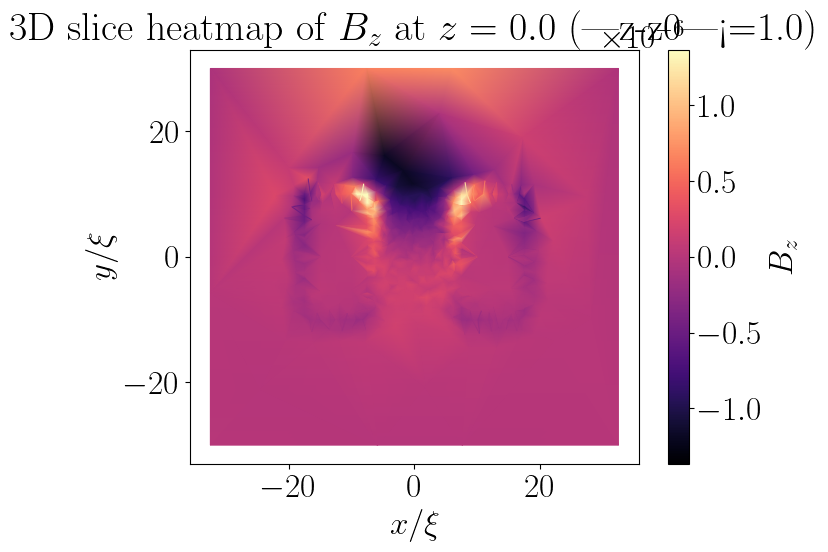

Source is: m = 1 | sigma: 15 | Coordinate: (0, 15, 0)


In [38]:
# import pickled object
class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        # Older checkpoints store RabiLondon2D as __main__.RabiLondon2D.
        # Remap to the current implementation class.
        if module == "__main__" and name == "RabiLondon2D":
            return RabiLondonSystem
        return super().find_class(module, name)


with open('3DRL7.pkl', 'rb') as f:
    pickle_obj = _CompatUnpickler(f).load()
    rabilondon = pickle_obj["rabilondon"]
    A_sol = pickle_obj["A_sol"]
    basis_edge = pickle_obj["basis_edge"]
    source_obj = pickle_obj["source_obj"]
    omega_d_rad_s = pickle_obj["omega_d_rad_s"]
    c_bar = pickle_obj["c_bar"]
    hamiltonian_time_data = pickle_obj["hamiltonian_time_data"]

# Visualize Solution
vis = VisualizeVF(rabilondon.mesh, basis_edge, A_sol)
vis.visualize_bz_slice_z0_3d(z0=0.0, tol=1.0, bz_symmetric_percentile=99.0, cmap="magma")

omega_d_nondim = rabilondon.omega_q

print(f"Source is: m = {source_obj['m']} | sigma: {source_obj['sigma']} | Coordinate: {source_obj['source_coord']}")

# Construct Rabi Hamiltonian

In [39]:
# Import A1 and A2 Matrices from pickle, and Pauli Decompose TLS Matrices
A1_mat, A2_mat = hamiltonian_time_data["A1_mat"], hamiltonian_time_data["A2_mat"]
A1_mat_TLS, A2_mat_TLS= rabilondon.TLS_matrix(A1_mat), rabilondon.TLS_matrix(A2_mat)
A1_mat_TLS_decomposed, A2_mat_TLS_decomposed = rabilondon.pauli_decompose(A1_mat_TLS), rabilondon.pauli_decompose(A2_mat_TLS)

print(f"A1I: {A1_mat_TLS_decomposed[0]} | A1X: {A1_mat_TLS_decomposed[1]} | A1Y: {A1_mat_TLS_decomposed[2]} | A1Z: {A1_mat_TLS_decomposed[3]}")
print(f"A2I: {A2_mat_TLS_decomposed[0]} | A2X: {A2_mat_TLS_decomposed[1]} | A2Y: {A2_mat_TLS_decomposed[2]} | A2Z: {A2_mat_TLS_decomposed[3]}")

a1_off_diag_max, a2_off_diag_max = np.max(np.abs(A1_mat_TLS - np.diag(np.diag(A1_mat_TLS)))), np.max(np.abs(A2_mat_TLS - np.diag(np.diag(A2_mat_TLS))))     
detuning_max = max(np.abs(A1_mat_TLS_decomposed[3]), np.abs(A2_mat_TLS_decomposed[3]))
a2z_detuning = np.real(A2_mat_TLS_decomposed[3])
print(f"A1 Off Diagonal Max: {a1_off_diag_max}")
print(f"A2 Off Diagonal Max: {a2_off_diag_max}\n")
print(f"Check that A1 off diagonal max is much much larger for Rabi Oscillations!! It is {a1_off_diag_max/a2_off_diag_max} times larger.")
print(f"Check that detuning is much lower too! Off diagonal of A1 is {a1_off_diag_max/a2z_detuning} times larger than the detuning (A1z and A2z).\n\n")

rabi_freq = np.sqrt(np.abs(A1_mat_TLS_decomposed[1])**2 + np.abs(A1_mat_TLS_decomposed[2])**2)  
rabi_period = float(2*np.pi/rabi_freq)
drive_period = float(2*np.pi/omega_d_nondim) # Remember Hamiltonian is nondimmed, so 1/energy or 1/time is nondimmed
print(f"Approx Rabi Frequency (Assuming x and y components of A2 are trivial): {rabi_freq}")
print(f"Rabi Period (nondim): {rabi_period} s")
print(f"Drive Period (nondim): {drive_period} s")
print(f"********* Ratio: {rabi_period/drive_period} *********\n\n")

print(f"Direct Detuning from A2Z Only (Since A2 has DC term): {a2z_detuning} | Fixing Drive Frequency by Adding Detuning")


# NEW DRIVE FREQUENCY ( + Detuning)
omega_d_nondim_new = (omega_d_nondim + 2*a2z_detuning)
drive_period_new = float(2*np.pi/omega_d_nondim_new)

A1I: -5.76868082958397e-17j | A1X: 0j | A1Y: (-4.266709652256395e-09+0j) | A1Z: -1.2185267086690105e-17j
A2I: (1.4217425847729004e-11+0j) | A2X: (1.5047422400986388e-13+0j) | A2Y: -4.54009659728305e-19j | A2Z: (7.741463720067898e-14+0j)
A1 Off Diagonal Max: 4.266709652256395e-09
A2 Off Diagonal Max: 1.5047467124326003e-13

Check that A1 off diagonal max is much much larger for Rabi Oscillations!! It is 28355.001953125 times larger.
Check that detuning is much lower too! Off diagonal of A1 is 55115.0234375 times larger than the detuning (A1z and A2z).


Approx Rabi Frequency (Assuming x and y components of A2 are trivial): 4.266709652256395e-09
Rabi Period (nondim): 1472606720.0 s
Drive Period (nondim): 5.031659676758381 s
********* Ratio: 292668187.95438063 *********


Direct Detuning from A2Z Only (Since A2 has DC term): 7.741463720067898e-14 | Fixing Drive Frequency by Adding Detuning


Time evolution:   0%|          | 0/399 [00:00<?, ?it/s]

[0.00000000e+00 1.10445431e+06 2.20890863e+06 ... 4.41560835e+09
 4.41671280e+09 4.41781726e+09] [0.00000000e+00 5.55163472e-06 2.22064156e-05 ... 2.22663069e-05
 5.58160089e-06 4.03287260e-11]
[[ 0.00000000e+00+0.00000000e+00j  1.00000000e+00+0.00000000e+00j]
 [-2.16389513e-11-2.35619072e-03j  9.99997224e-01+8.55062291e-08j]
 [-4.32633532e-11-4.71236836e-03j  9.99988897e-01+1.71011984e-07j]
 ...
 [ 1.41174896e-11-4.71871878e-03j -9.99988867e-01+1.59057815e-07j]
 [ 7.07548964e-12-2.36254119e-03j -9.99997209e-01+7.35519613e-08j]
 [ 1.92840353e-14-6.35049022e-06j -1.00000000e+00-1.19543015e-08j]]


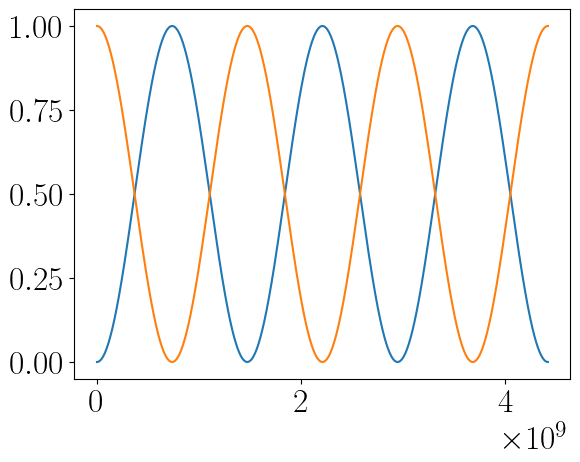

In [50]:
# Construct TLS Hamiltonian in Interaction Picture (rotated at DRIVE frequency, not typical H0)
H_tls_interaction = rabilondon.rabi_hamiltonian_tls_interaction_picture(basis_edge,A_sol,omega_d_nondim_new,A1_mat_TLS_decomposed,A2_mat_TLS_decomposed)

# Evolve for Rabi Oscillations
states, t_strob = rabilondon.rabi_efficient(H_tls_interaction,drive_period_new,400,rabi_period*3,4000)


# Plot
pop0, pop1 = np.abs(states[:, 0])**2, np.abs(states[:, 1])**2
plt.plot(t_strob, pop0)
plt.plot(t_strob, pop1)
print(t_strob,pop0)
print(states)

## Generate the Figure

Fitted omega: 4.26670965e-09
Omega std err: 3.04e-17
RMSE: 6.45e-08
576
London fit (from 2D section): A=-1.17e-06, tau=52.1, C=9.69e-07, tau_std=618


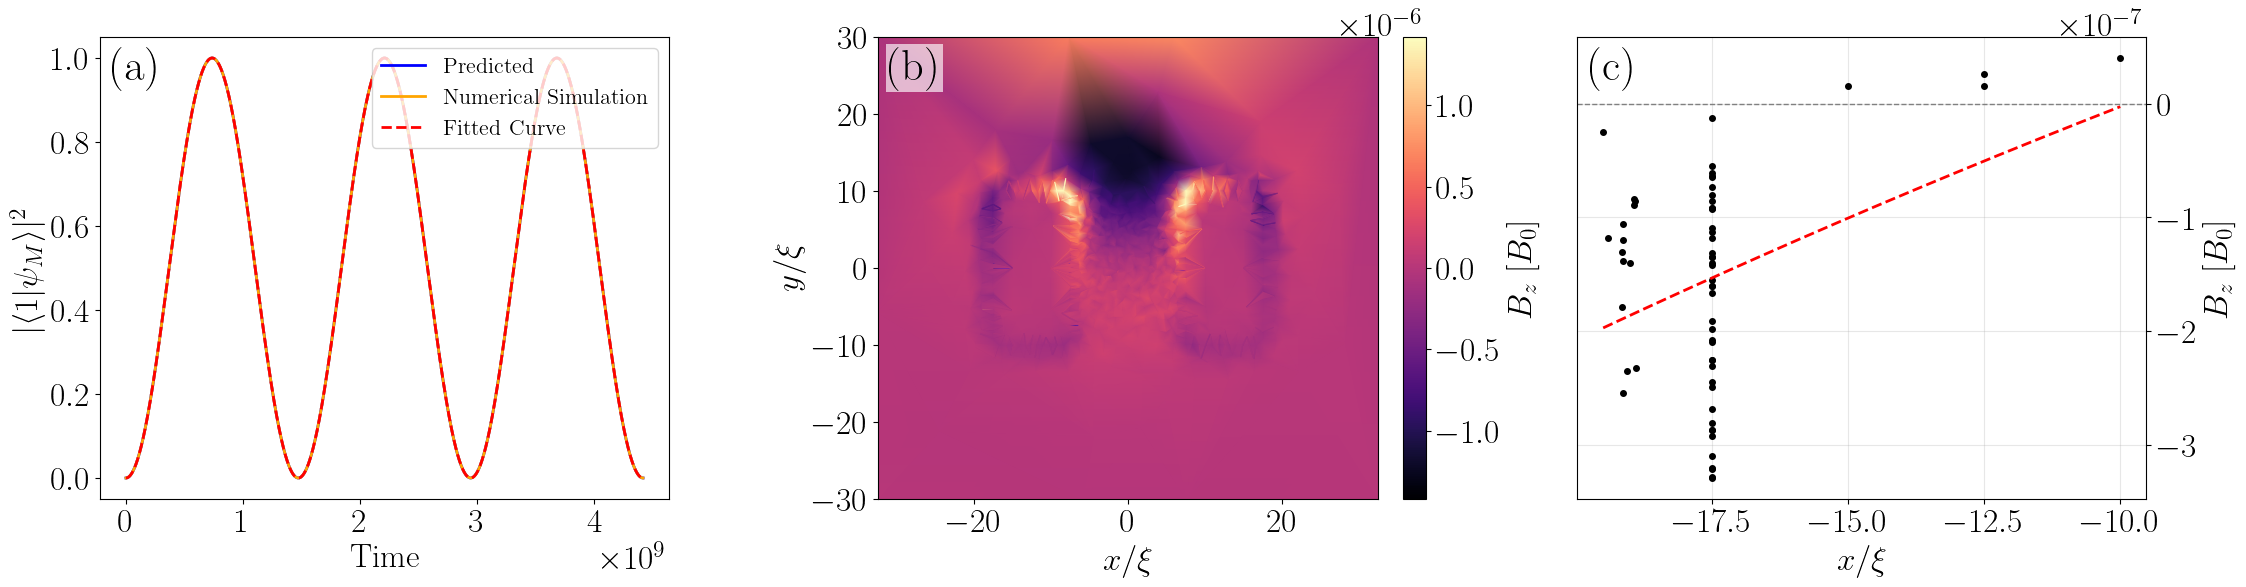

In [55]:
from scipy.optimize import curve_fit
from skfem import Basis, ElementTetP1, BilinearForm, LinearForm, asm
from skfem.helpers import curl
from scipy.sparse.linalg import spsolve
from matplotlib.tri import Triangulation

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 24,
})

# Create a 2D slice from the 3D mesh using basis_edge quadrature (robust to nq=14)
z_cut, z_tol = 0.0, 2.0
basis_p1_3d = Basis(rabilondon.mesh, ElementTetP1(), quadrature=basis_edge.quadrature)

@BilinearForm
def mass_matrix_scalar(u, v, w):
    return u * v

@LinearForm
def rhs_bz(v, w):
    return curl(w["A_edge"])[2] * v

M_s = asm(mass_matrix_scalar, basis_p1_3d)
b_s = asm(rhs_bz, basis_p1_3d, A_edge=basis_edge.interpolate(A_sol))
Bz_nodes = np.asarray(spsolve(M_s, b_s)).ravel()

x_all = np.asarray(basis_p1_3d.doflocs[0]).ravel()
y_all = np.asarray(basis_p1_3d.doflocs[1]).ravel()
z_all = np.asarray(basis_p1_3d.doflocs[2]).ravel()

slice_mask = np.abs(z_all - z_cut) <= z_tol
if np.count_nonzero(slice_mask) < 3:
    raise ValueError(f"Slice has too few points at z={z_cut} with tol={z_tol}; increase z_tol.")

x_slice = x_all[slice_mask]
y_slice = y_all[slice_mask]
bz_slice = Bz_nodes[slice_mask]

# Create three plots side-by-side with dynamic middle-column width
x_span = float(np.max(x_slice) - np.min(x_slice))
y_span = float(np.max(y_slice) - np.min(y_slice))
mid_ratio = float(np.clip((x_span / y_span) if y_span > 0 else 1.0, 0.7, 2.0))

fig = plt.figure(figsize=(22, 6), constrained_layout=False)
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, mid_ratio, 1.0], wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])


'''
Plot 1: Rabi Oscillations (efficient method)
'''
# Use the already computed efficient dynamics from the previous cell.
sample_t = np.asarray(t_strob, dtype=float)
state1_pop = np.asarray(np.abs(states[:, 0])**2, dtype=float)


def rabi_model(t, omega):
    return 0.5 * (1.0 - np.cos(omega * t))


omega0 = float(np.real(rabi_freq)) if np.ndim(rabi_freq) == 0 else float(np.real(rabi_freq[0]))

try:
    popt, pcov = curve_fit(
        rabi_model,
        sample_t,
        state1_pop,
        p0=[max(omega0, 1e-12)],
        bounds=(0.0, np.inf),
    )
    omega_fit = float(popt[0])
    omega_fit_std = float(np.sqrt(np.diag(pcov))[0]) if np.isfinite(pcov).all() else np.nan
    fit_vals = rabi_model(sample_t, omega_fit)
    rmse = float(np.sqrt(np.mean((state1_pop - fit_vals) ** 2)))

    print(f"Fitted omega: {omega_fit:.9g}")
    print(f"Omega std err: {omega_fit_std:.3g}")
    print(f"RMSE: {rmse:.3g}")
except Exception as e:
    omega_fit = np.nan
    fit_vals = np.full_like(sample_t, np.nan)
    print("Fit failed:", e)

predicted_population = rabi_model(sample_t, float(np.real(rabi_freq)))

ax1.plot(sample_t, predicted_population, "-", color="blue", lw=2, label="Predicted")
ax1.plot(sample_t, state1_pop, "-", color="orange", lw=2, label="Numerical Simulation")
if np.isfinite(omega_fit):
    ax1.plot(sample_t, fit_vals, "--", lw=2, color="red", label="Fitted Curve")

ax1.set_xlabel("Time")
ax1.set_ylabel(r"$|\langle 1 | \psi_M \rangle|^2$")
ax1.legend(loc="upper right", fontsize=16)

'''
Plot 2: 2D cross section (3D geometry)
'''
tri2d = Triangulation(x_slice, y_slice)
kw = dict(shading="gouraud", cmap="magma")
lim = np.percentile(np.abs(bz_slice), 99.0)
if lim > 0:
    kw["vmin"], kw["vmax"] = -float(lim), float(lim)
tpc = ax2.tripcolor(tri2d, bz_slice, **kw)
plt.colorbar(tpc, ax=ax2, label="$B_z$ $[B_0]$", fraction=0.046, pad=0.04)
ax2.set_xlim(np.min(x_slice), np.max(x_slice))
ax2.set_ylim(np.min(y_slice), np.max(y_slice))
if x_span > 0 and y_span > 0:
    ax2.set_box_aspect(y_span / x_span)
ax2.set_aspect("equal", adjustable="box")
ax2.set_xlabel(r"$x/\xi$")
ax2.set_ylabel(r"$y/\xi$")

'''
Plot 3: 1D London fit of panel-2 cross section
'''
y_cut, y_tol = 0.0, 5.0
line_mask = np.isclose(y_slice, y_cut, atol=y_tol)
if np.count_nonzero(line_mask) < 4:
    y_band = max(np.percentile(np.abs(y_slice - y_cut), 8), 1e-9)
    line_mask = np.abs(y_slice - y_cut) <= y_band

x_line = np.asarray(x_slice[line_mask]).ravel()
bz_line = np.asarray(bz_slice[line_mask]).ravel()

order = np.argsort(x_line)
x_line = x_line[order]
bz_line = bz_line[order]

xmin, xmax = -20, -10
fit_mask = (x_line >= xmin) & (x_line <= xmax)

print(len(fit_mask))

if np.count_nonzero(fit_mask) < 4:
    fit_mask = np.ones_like(x_line, dtype=bool)

x_fit_data = x_line[fit_mask]
bz_fit_data = bz_line[fit_mask]

x0 = float(np.min(x_fit_data))

def exp_decay_shifted(x, A, tau, C):
    return A * np.exp(-(x - x0) / tau) + C

A0 = float(np.max(bz_fit_data) - np.min(bz_fit_data))
tau0 = float(max((np.max(x_fit_data) - np.min(x_fit_data)) / 2.0, 1e-9))
C0 = float(np.min(bz_fit_data))

popt, pcov = curve_fit(
    exp_decay_shifted,
    x_fit_data,
    bz_fit_data,
    p0=[A0, tau0, C0],
    bounds=([-np.inf, 1e-12, -np.inf], [np.inf, np.inf, np.inf]),
)
A_opt, tau_opt, C_opt = [float(v) for v in popt]
tau_std = float(np.sqrt(np.diag(pcov))[1]) if np.isfinite(pcov).all() else np.nan
print(
    f"London fit (from 2D section): A={A_opt:.3g}, tau={tau_opt:.3g}, C={C_opt:.3g}, tau_std={tau_std:.3g}"
)

ax3.plot(x_fit_data, bz_fit_data, "o", color="black", ms=4, lw=1.5)
x_dense = np.linspace(float(np.min(x_fit_data)), float(np.max(x_fit_data)), 200)
ax3.plot(x_dense, exp_decay_shifted(x_dense, *popt), "r--", lw=2)
ax3.axhline(0.0, color="gray", linestyle="--", lw=1)
ax3.set_xlabel(r"$x/\xi$")
ax3.set_ylabel(r"$B_z$ $[B_0]$")
ax3.grid(alpha=0.3)

# Avoid collision with panel-2 colorbar text.
ax3.yaxis.set_label_position("right")
ax3.yaxis.tick_right()
ax3.tick_params(axis="y", pad=4)

# Panel labels
for ax, lab in zip([ax1, ax2, ax3], ["(a)", "(b)", "(c)"]):
    ax.text(
        0.02, 0.98, lab,
        transform=ax.transAxes,
        ha="left", va="top",
        fontweight="bold",
        fontsize=32,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=1.2),
    )

fig.subplots_adjust(left=0.05, right=0.98, bottom=0.18, top=0.95, wspace=0.12)